## 🛍️ Gender_EDA_Extended

> 기본 EDA에서 구축한 **교수님 baseline 78 feature**를 대상으로,
> 성별 (0=여, 1=남) 분류에 실제로 유효한 시그널을 탐색하고 추가 feature engineering 방향을 도출한다.
___

### 📚 목차
***1. 타깃 분포 — class balance, Wilson CI***  
***2. Baseline 수치형 univariate — 분포·왜도·log 변환***  
***3. Baseline 비중(ratio_*) 그룹 분석***  
***4. Bivariate vs gender — 카테고리 lift, bin별 P(남), MI***  
***5. 시간 패턴 — 요일/시간/월 및 season·time_zone 비중***  
***6. 행동/집중도 feature 성별 분리도 — refund·import·installment·max_*_ratio***  
***7. Feature Importance 사전 평가 (Logistic + RF)***  
***8. Summary & Feature Engineering 체크리스트***

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 200)
plt.rcParams['axes.unicode_minus'] = False

import platform
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

In [3]:
train_tx = pd.read_csv('../data/raw/train_transactions.csv', encoding='cp949')
y_train  = pd.read_csv('../data/raw/y_train.csv',            encoding='cp949')
train_tx['sales_datetime'] = pd.to_datetime(train_tx['sales_datetime'])
tx = train_tx.merge(y_train, on='custid', how='left')

cust = pd.read_parquet('../data/interim/cust_train_baseline.parquet')
print('tx:', tx.shape, ' | cust:', cust.shape)
print('baseline feature 수:', cust.shape[1]-2)  # custid, gender 제외

tx: (1036653, 17)  | cust: (30000, 80)
baseline feature 수: 78


In [4]:
# 그룹 정의 (기본 노트북과 동일)
base_cols   = ['total_txn_cnt','unique_goods','unique_brand','unique_corner','unique_pc',
               'unique_part','unique_team','unique_store','visit_days',
               'goods_diversity','brand_diversity','txn_per_visit']
amt_cols    = ['total_net','mean_net','max_net','min_net','std_net','median_net',
               'total_tot','total_dis','discount_rate','amt_per_visit']
beh_cols    = ['refund_ratio','import_ratio','installment_ratio','mean_inst_mon','weekend_ratio']
team_cols   = [c for c in cust.columns if c.startswith('ratio_team_')]
part_cols   = [c for c in cust.columns if c.startswith('ratio_part_')]
season_cols = [c for c in cust.columns if c.startswith('ratio_season_')]
time_cols   = [c for c in cust.columns if c.startswith('ratio_time_')]
store_cols  = [c for c in cust.columns if c.startswith('ratio_store_')]
conc_cols   = ['max_team_ratio','max_part_ratio','max_season_ratio']

all_numeric = base_cols + amt_cols + beh_cols + team_cols + part_cols + \
              season_cols + time_cols + store_cols + conc_cols

### ***1. 타깃 분포 — class balance, Wilson CI***

P(남=1) = 0.30393  (Wilson 95% CI: [0.29875, 0.30916])
남(1): 9,118  /  여(0): 20,882   ratio 1 : 2.29


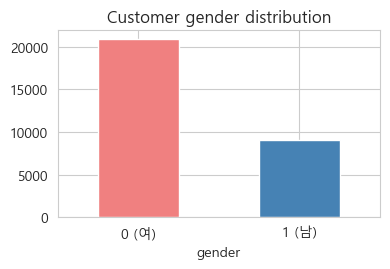

In [6]:
from statsmodels.stats.proportion import proportion_confint

def wilson_ci(k, n, alpha=0.05):
    if n == 0: return (np.nan, np.nan)
    return proportion_confint(k, n, alpha=alpha, method='wilson')

n = len(cust)
k = int((cust['gender']==1).sum())
base_p_male = k/n
lo, hi = wilson_ci(k, n)
print(f'P(남=1) = {base_p_male:.5f}  (Wilson 95% CI: [{lo:.5f}, {hi:.5f}])')
print(f'남(1): {k:,}  /  여(0): {n-k:,}   ratio 1 : {(n-k)/k:.2f}')

cust['gender'].value_counts().sort_index().plot(
    kind='bar', color=['lightcoral','steelblue'], figsize=(4,2.8))
plt.xticks([0,1], ['0 (여)','1 (남)'], rotation=0)
plt.title('Customer gender distribution'); plt.tight_layout(); plt.show()

### ***2. Baseline 수치형 univariate***

> base + 금액 + 행동 비율 feature의 왜도/첨도 확인 후 log1p 후보 식별.

In [8]:
num_cols_main = base_cols + amt_cols + beh_cols + conc_cols

skew_tbl = (cust[num_cols_main].skew().to_frame('skew')
              .join(cust[num_cols_main].kurt().to_frame('kurt'))
              .join(cust[num_cols_main].nunique().to_frame('nunique'))
              .sort_values('skew', key=lambda s: s.abs(), ascending=False))
display(skew_tbl)

,skew,kurt,nunique
min_net,-36.298647,3202.002768,7048
median_net,20.380719,1452.026196,9721
mean_net,18.246994,1204.731534,28588
max_net,17.624091,833.835906,6701
std_net,9.076837,200.477370,29035
total_dis,7.852220,110.275327,14404
amt_per_visit,6.668411,139.949299,28520
discount_rate,-5.769656,527.844209,28807
total_tot,5.144056,49.625067,26010
total_net,5.143151,49.970103,28125


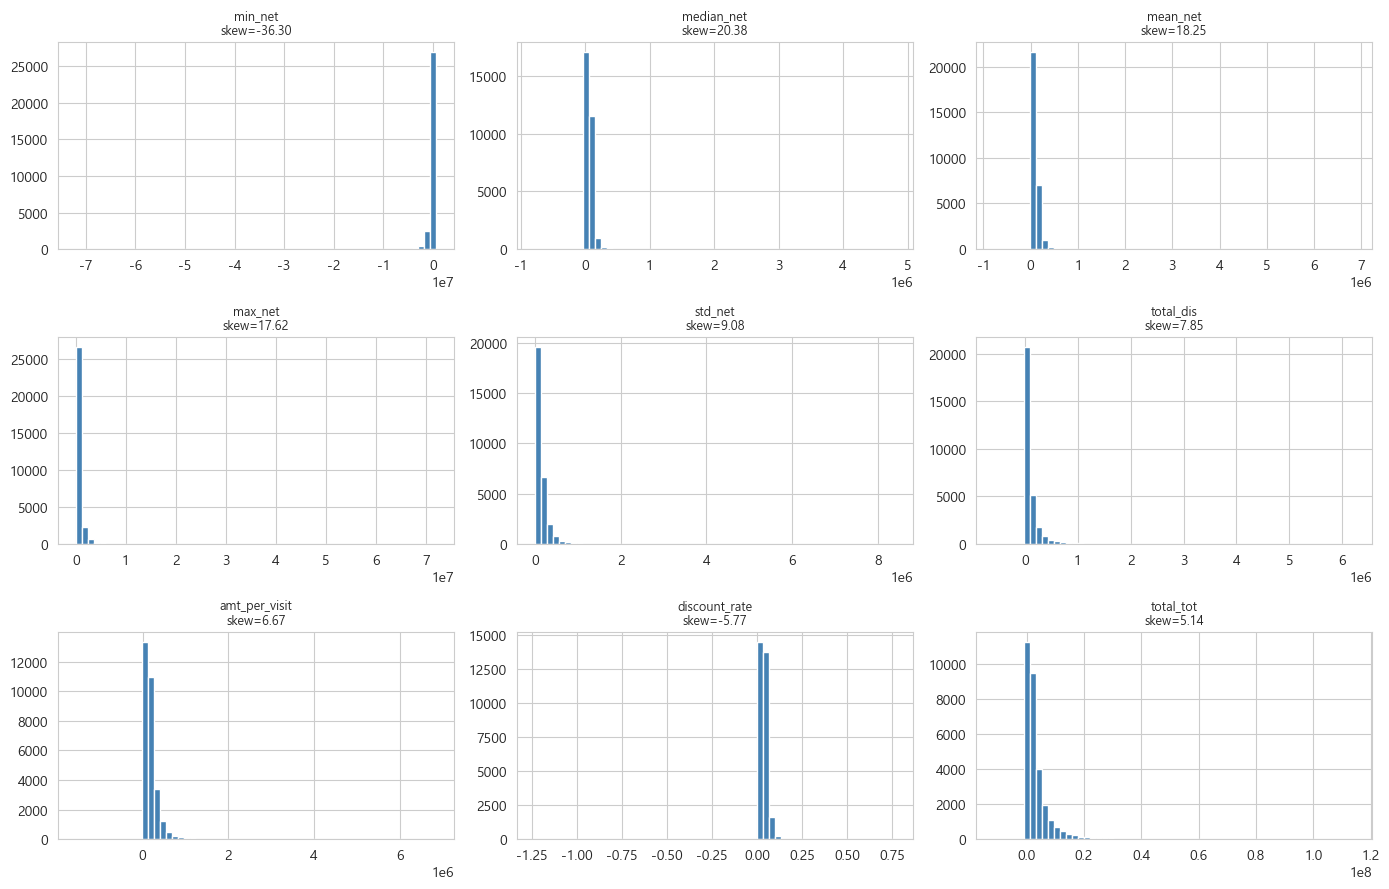

In [9]:
top_skew = skew_tbl.head(9).index.tolist()
fig, axes = plt.subplots(3,3, figsize=(14,9))
for ax, c in zip(axes.flatten(), top_skew):
    ax.hist(cust[c].dropna(), bins=60, color='steelblue')
    ax.set_title(f'{c}\nskew={skew_tbl.loc[c,"skew"]:.2f}', fontsize=9)
plt.tight_layout(); plt.show()

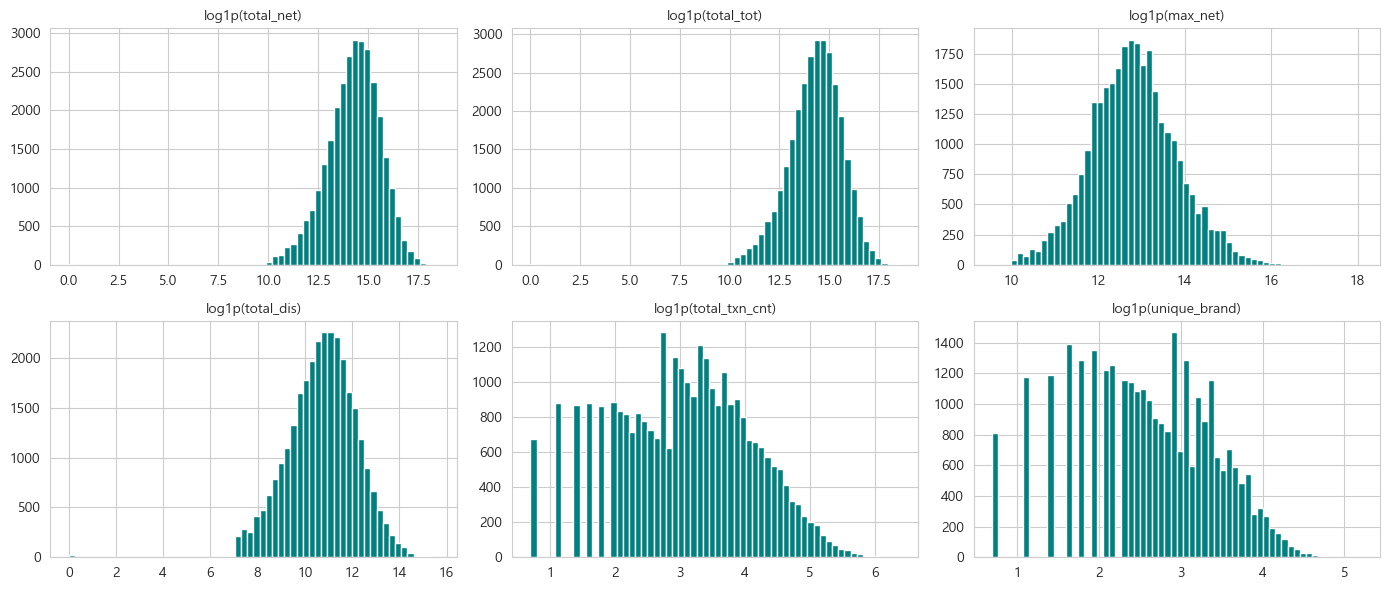

In [10]:
# log1p 변환 후보 비교
log_targets = ['total_net','total_tot','max_net','total_dis','total_txn_cnt','unique_brand']
fig, axes = plt.subplots(2,3, figsize=(14,6))
for ax, c in zip(axes.flatten(), log_targets):
    s = np.log1p(cust[c].clip(lower=0))
    ax.hist(s.dropna(), bins=60, color='teal')
    ax.set_title(f'log1p({c})', fontsize=10)
plt.tight_layout(); plt.show()

### ***3. Baseline 비중(ratio_*) 그룹 분석***

> `ratio_team_*`, `ratio_part_*`, `ratio_store_*`, `ratio_season_*`, `ratio_time_*` 비중 feature는
> 모든 고객에 대해 합이 1인 simplex 위 분포. 카테고리별 평균/분산을 보고 어떤 카테고리가 변동이 큰지(개인차 큰지) 확인한다.

In [12]:
def ratio_overview(cols, title):
    s = cust[cols].agg(['mean','std','min','max']).T.sort_values('mean', ascending=False)
    display(Markdown(f'#### {title}'))
    display(s)

ratio_overview(team_cols,   'ratio_team_* — team별 평균 비중')
ratio_overview(part_cols,   'ratio_part_* — part별 평균 비중')
ratio_overview(season_cols, 'ratio_season_*')
ratio_overview(time_cols,   'ratio_time_*')
ratio_overview(store_cols,  'ratio_store_*')

#### ratio_team_* — team별 평균 비중

,mean,std,min,max
ratio_team_잡화가용팀,5.212038e-01,0.225333,0.0,1.000000
ratio_team_의류패션팀,3.250811e-01,0.207412,0.0,1.000000
ratio_team_식품팀,1.537140e-01,0.189353,0.0,1.000000
ratio_team_인터넷백화점,7.575758e-07,0.000131,0.0,0.022727
ratio_team_상품개발영업2과,3.875969e-07,0.000067,0.0,0.011628


#### ratio_part_* — part별 평균 비중

,mean,std,min,max
ratio_part_명품잡화,1.077035e-01,0.189389,0.0,1.000000
ratio_part_패션잡화,9.343590e-02,0.178126,0.0,1.000000
ratio_part_잡화파트,8.965469e-02,0.171665,0.0,1.000000
ratio_part_공산품,6.980504e-02,0.111749,0.0,1.000000
"ratio_part_케주얼,구두,아동",6.145288e-02,0.125258,0.0,1.000000
ratio_part_잡화,4.962918e-02,0.135291,0.0,1.000000
ratio_part_영플라자,4.577237e-02,0.115133,0.0,1.000000
ratio_part_여성캐주얼,4.229891e-02,0.087421,0.0,1.000000
ratio_part_생식품,4.203931e-02,0.085362,0.0,0.788462
ratio_part_가정용품,3.966949e-02,0.075869,0.0,1.000000


#### ratio_season_*

,mean,std,min,max
ratio_season_봄,0.281906,0.227281,0.0,1.0
ratio_season_여름,0.250104,0.212637,0.0,1.0
ratio_season_가을,0.235273,0.198606,0.0,1.0
ratio_season_겨울,0.232717,0.202368,0.0,1.0


#### ratio_time_*

,mean,std,min,max
ratio_time_오후,0.392978,0.224878,0.0,1.0
ratio_time_점심,0.292995,0.218354,0.0,1.0
ratio_time_저녁,0.237230,0.229183,0.0,1.0
ratio_time_오전,0.076797,0.128374,0.0,1.0


#### ratio_store_*

,mean,std,min,max
ratio_store_무역점,0.294082,0.387593,0.0,1.0
ratio_store_신촌점,0.270181,0.410816,0.0,1.0
ratio_store_본점,0.254600,0.371354,0.0,1.0
ratio_store_천호점,0.181136,0.358483,0.0,1.0


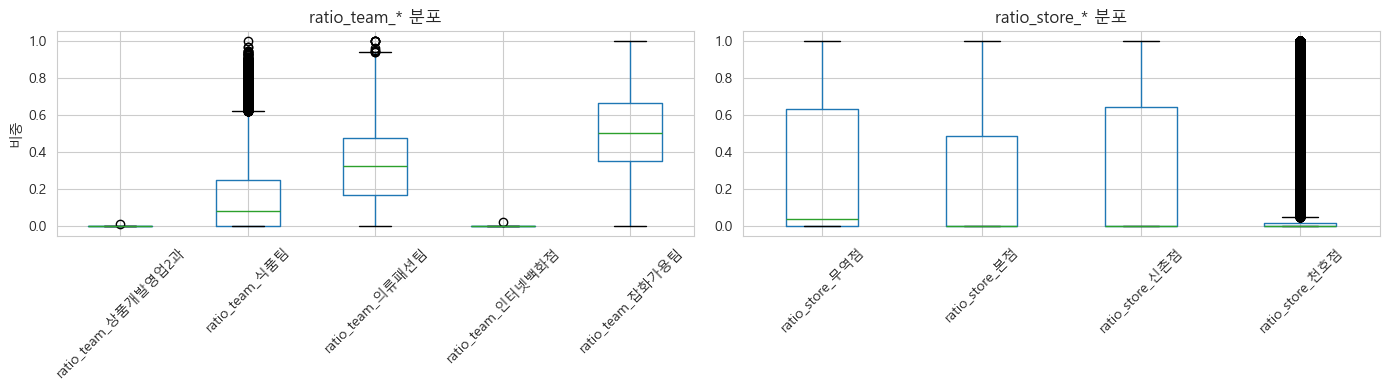

In [13]:
# team / store 비중 box plot — 변동성 시각화
fig, axes = plt.subplots(1,2, figsize=(14,4))
cust[team_cols].boxplot(ax=axes[0], rot=45)
axes[0].set_title('ratio_team_* 분포'); axes[0].set_ylabel('비중')
cust[store_cols].boxplot(ax=axes[1], rot=45)
axes[1].set_title('ratio_store_* 분포')
plt.tight_layout(); plt.show()

### ***4. Bivariate vs gender***

#### ***4-1. 거래 단위 카테고리 lift table***

> 어떤 점포/팀/코너/브랜드에서 P(남=1)이 baseline과 다른지 — Wilson CI로 노이즈 제거.

In [15]:
def lift_table(df, col, min_count=200):
    g = df.groupby(col)['gender'].agg(['sum','count'])
    g = g[g['count']>=min_count].copy()
    g['p_male'] = g['sum']/g['count']
    g['lift']   = g['p_male']/base_p_male
    ci = g.apply(lambda r: wilson_ci(int(r['sum']), int(r['count'])), axis=1)
    g['lo'] = [c[0] for c in ci]; g['hi'] = [c[1] for c in ci]
    return g.sort_values('lift', ascending=False)

for col in ['str_nm','team_nm','part_nm','pc_nm','corner_nm']:
    t = lift_table(tx, col, min_count=500)
    display(Markdown(f'#### 📌 **{col} — lift 상/하위 10**'))
    display(pd.concat([t.head(10), t.tail(10)]))

#### 📌 **str_nm — lift 상/하위 10**

,sum,count,p_male,lift,lo,hi
str_nm,,,,,,
본점,134229,299735,0.447826,1.473434,0.446046,0.449606
무역점,102253,284226,0.359759,1.183679,0.357997,0.361526
천호점,69328,203089,0.341368,1.123166,0.339308,0.343433
신촌점,71980,249603,0.288378,0.948820,0.286604,0.290158
본점,134229,299735,0.447826,1.473434,0.446046,0.449606
무역점,102253,284226,0.359759,1.183679,0.357997,0.361526
천호점,69328,203089,0.341368,1.123166,0.339308,0.343433
신촌점,71980,249603,0.288378,0.948820,0.286604,0.290158


#### 📌 **team_nm — lift 상/하위 10**

,sum,count,p_male,lift,lo,hi
team_nm,,,,,,
식품팀,93627,234779,0.398788,1.312090,0.396809,0.400770
의류패션팀,121538,342245,0.355120,1.168414,0.353518,0.356725
잡화가용팀,162624,459627,0.353817,1.164128,0.352436,0.355201
식품팀,93627,234779,0.398788,1.312090,0.396809,0.400770
의류패션팀,121538,342245,0.355120,1.168414,0.353518,0.356725
잡화가용팀,162624,459627,0.353817,1.164128,0.352436,0.355201


#### 📌 **part_nm — lift 상/하위 10**

,sum,count,p_male,lift,lo,hi
part_nm,,,,,,
남성정장스포츠,13530,26776,0.505303,1.662546,0.499314,0.511291
생식품파트,16592,33192,0.499879,1.644701,0.494501,0.505258
공산품파트,20529,43073,0.476609,1.568138,0.471895,0.481328
가정용품파트,8316,17769,0.468006,1.539831,0.460677,0.475349
"케주얼,구두,아동",32269,71342,0.452314,1.488202,0.448665,0.455969
로얄부띠끄,5127,11378,0.450606,1.482583,0.441482,0.459764
"아동,스포츠",14370,34111,0.421272,1.386066,0.416041,0.426520
로얄부틱,1747,4297,0.406563,1.337671,0.391966,0.421326
골프/유니캐쥬얼,13202,32569,0.405355,1.333696,0.400034,0.410698


#### 📌 **pc_nm — lift 상/하위 10**

,sum,count,p_male,lift,lo,hi
pc_nm,,,,,,
아동복,7530,14560,0.517170,1.701591,0.509050,0.525281
문화용품,4267,8270,0.515961,1.697613,0.505186,0.526722
"침구,수예",887,1752,0.506279,1.665755,0.482880,0.529650
트레디셔널,3653,7664,0.476644,1.568252,0.465477,0.487835
정장,4390,9474,0.463373,1.524589,0.453349,0.473427
캐릭터정장,3646,7962,0.457925,1.506663,0.447004,0.468887
로얄부띠끄,5128,11379,0.450655,1.482742,0.441531,0.459812
남성잡화,893,2022,0.441642,1.453088,0.420128,0.463377
골프,12935,29637,0.436448,1.435998,0.430810,0.442102


#### 📌 **corner_nm — lift 상/하위 10**

,sum,count,p_male,lift,lo,hi
corner_nm,,,,,,
DC캐주얼,367,696,0.527299,1.734916,0.490160,0.564138
아동특선,663,1302,0.509217,1.675422,0.482075,0.536304
문구,403,817,0.493268,1.622948,0.459098,0.527501
임대골프,356,722,0.493075,1.622312,0.456740,0.529482
테이프,841,1709,0.492101,1.619107,0.468443,0.515794
수입구두,497,1026,0.484405,1.593789,0.453941,0.514986
골프단품,607,1256,0.483280,1.590086,0.455737,0.510925
상품개발지원,342,709,0.482370,1.587090,0.445783,0.519147
캐릭터캐주얼,1987,4134,0.480648,1.581427,0.465443,0.495889


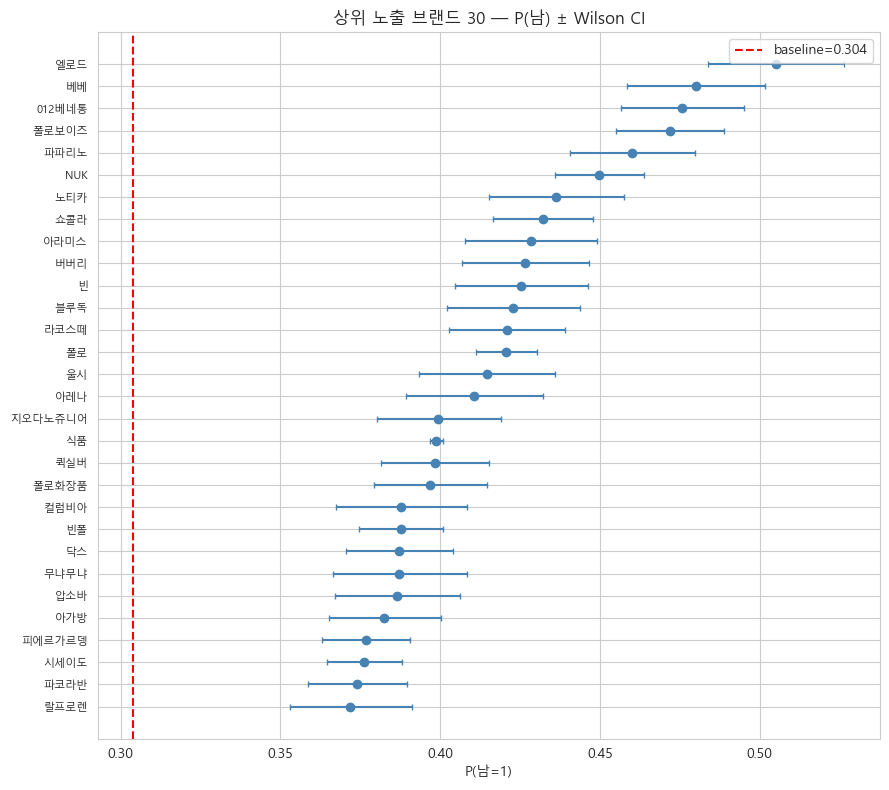

In [16]:
# 상위 노출 브랜드 30개 — P(남) ± Wilson CI
t_brd = lift_table(tx, 'brd_nm', min_count=2000).head(30)
fig, ax = plt.subplots(figsize=(9,8))
ax.errorbar(t_brd['p_male'], range(len(t_brd)),
            xerr=[t_brd['p_male']-t_brd['lo'], t_brd['hi']-t_brd['p_male']],
            fmt='o', color='steelblue', capsize=2)
ax.axvline(base_p_male, color='red', ls='--', label=f'baseline={base_p_male:.3f}')
ax.set_yticks(range(len(t_brd))); ax.set_yticklabels(t_brd.index, fontsize=8)
ax.invert_yaxis(); ax.set_xlabel('P(남=1)'); ax.set_title('상위 노출 브랜드 30 — P(남) ± Wilson CI')
ax.legend(); plt.tight_layout(); plt.show()

#### ***4-2. Baseline 수치형 bin별 P(남)***

> 교수님 baseline feature를 구간화하여 단조성 / 임계 / noise 여부를 본다.

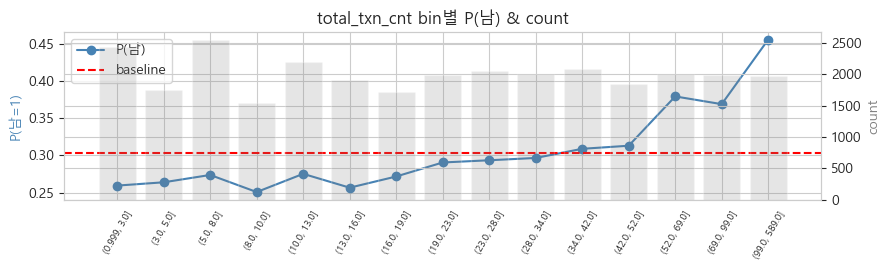

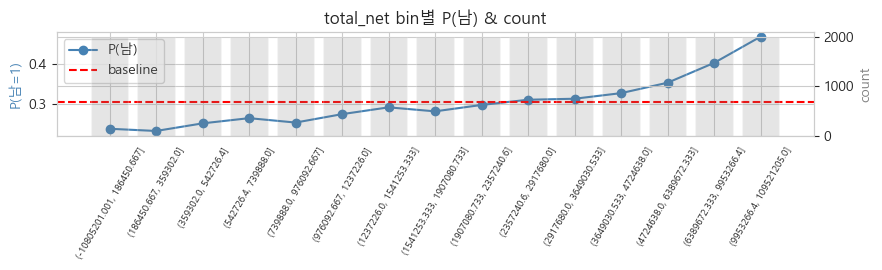

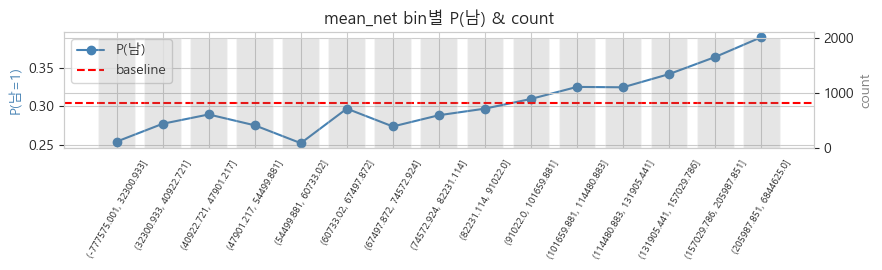

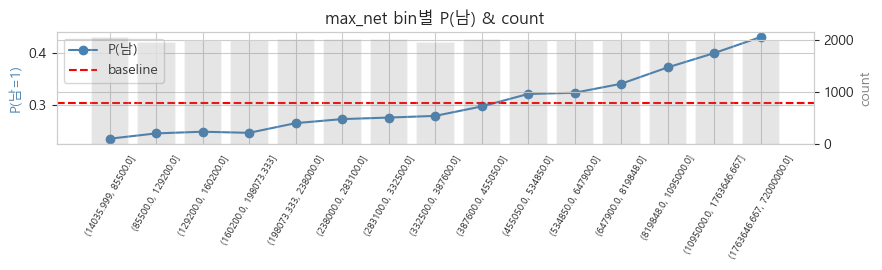

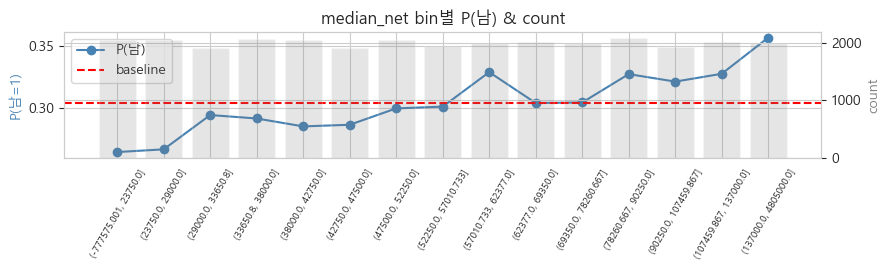

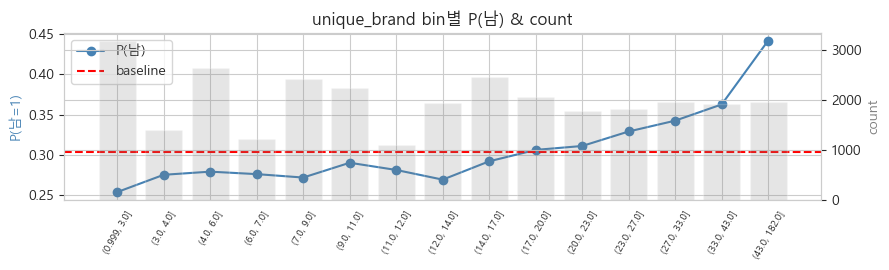

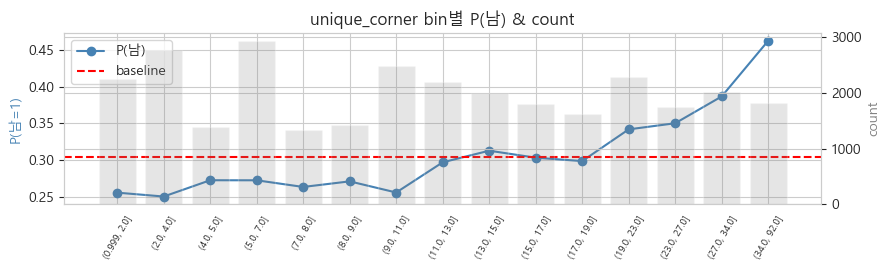

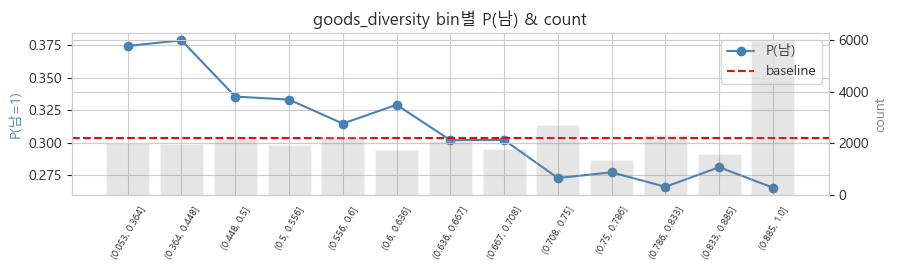

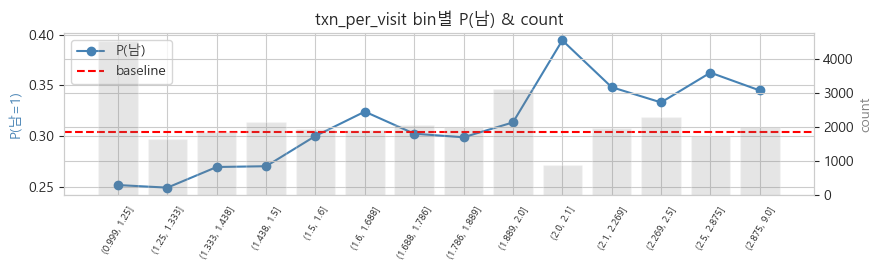

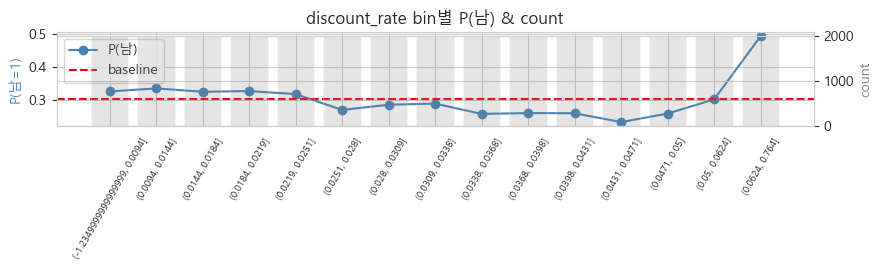

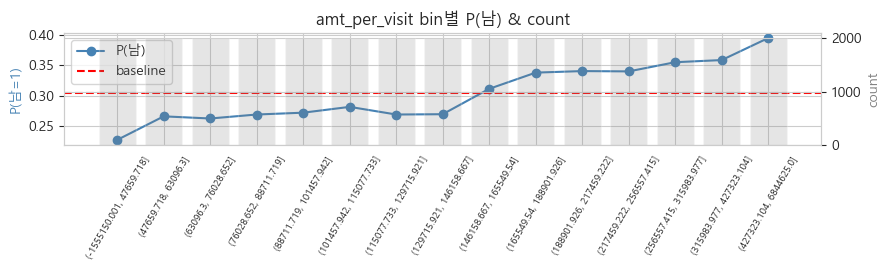

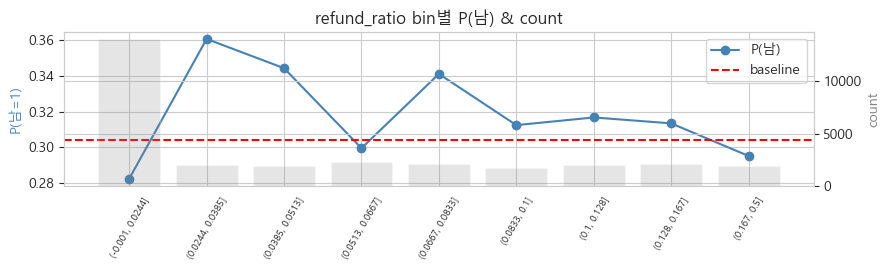

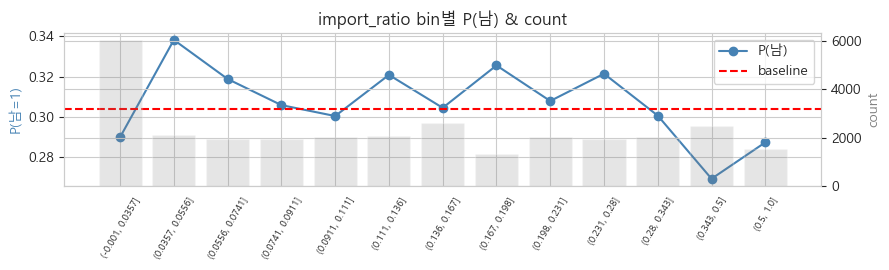

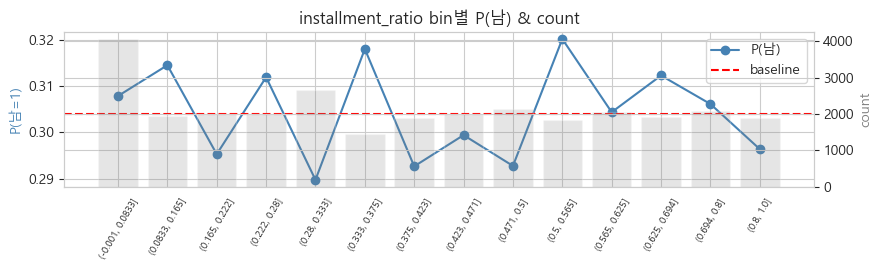

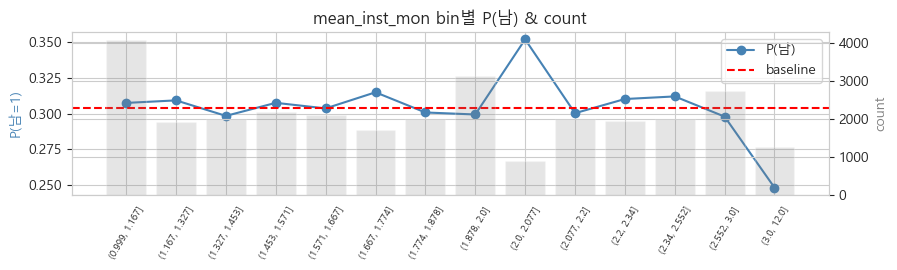

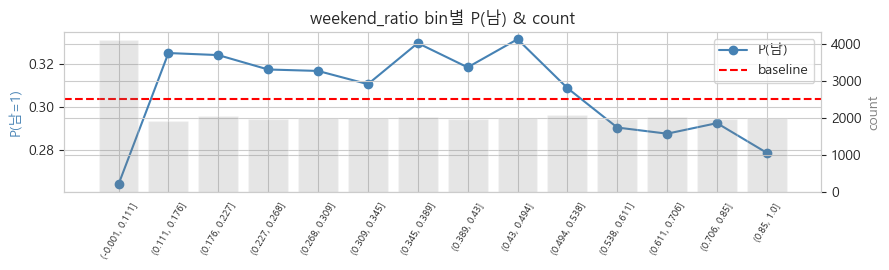

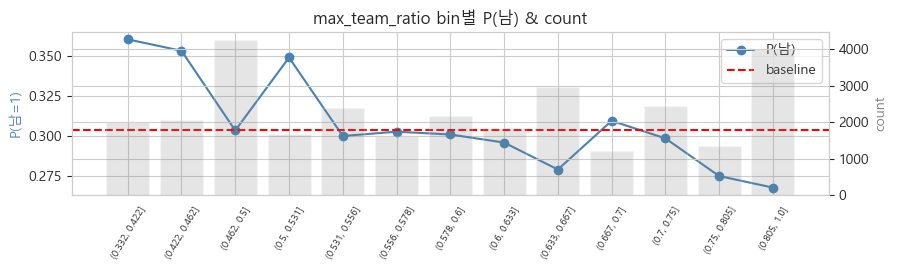

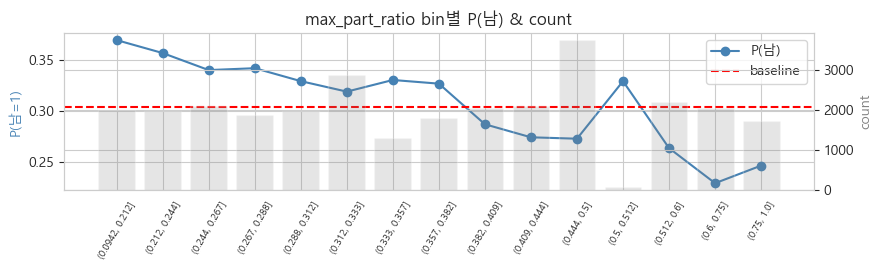

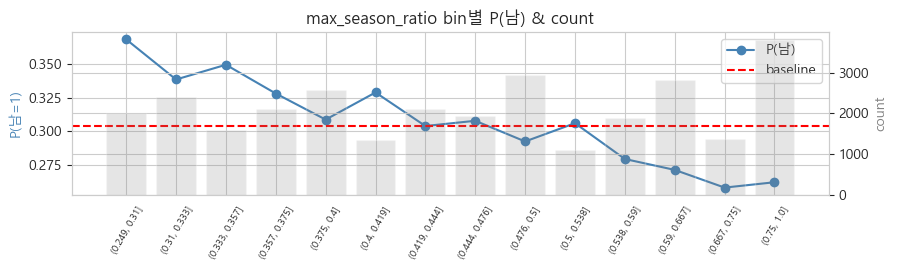

In [18]:
def binned_p_plot(df, col, bins=15):
    s = df[[col,'gender']].dropna().copy()
    if s[col].nunique() < 5: return
    try:
        s['bin'] = pd.qcut(s[col], q=min(bins, s[col].nunique()), duplicates='drop')
    except Exception as e:
        print(col, e); return
    g = s.groupby('bin')['gender'].agg(['mean','count'])
    fig, ax1 = plt.subplots(figsize=(9,2.8))
    ax1.plot(range(len(g)), g['mean'], 'o-', color='steelblue', label='P(남)')
    ax1.axhline(base_p_male, color='red', ls='--', label='baseline')
    ax1.set_ylabel('P(남=1)', color='steelblue')
    ax2 = ax1.twinx()
    ax2.bar(range(len(g)), g['count'], alpha=0.2, color='gray')
    ax2.set_ylabel('count', color='gray')
    ax1.set_xticks(range(len(g)))
    ax1.set_xticklabels([str(b) for b in g.index], rotation=60, fontsize=7)
    ax1.set_title(f'{col} bin별 P(남) & count'); ax1.legend()
    fig.tight_layout(); plt.show()

priority = ['total_txn_cnt','total_net','mean_net','max_net','median_net',
            'unique_brand','unique_corner','goods_diversity','txn_per_visit',
            'discount_rate','amt_per_visit',
            'refund_ratio','import_ratio','installment_ratio','mean_inst_mon','weekend_ratio',
            'max_team_ratio','max_part_ratio','max_season_ratio']
for c in priority:
    if c in cust.columns:
        binned_p_plot(cust, c)

#### ***4-3. Mutual Information (전체 baseline feature)***

,MI
total_tot,0.012728
max_net,0.011846
ratio_time_오전,0.010820
total_net,0.010609
discount_rate,0.010461
total_txn_cnt,0.010323
ratio_part_남성정장스포츠,0.009854
median_net,0.009733
ratio_part_패션잡화,0.009414
unique_team,0.009380


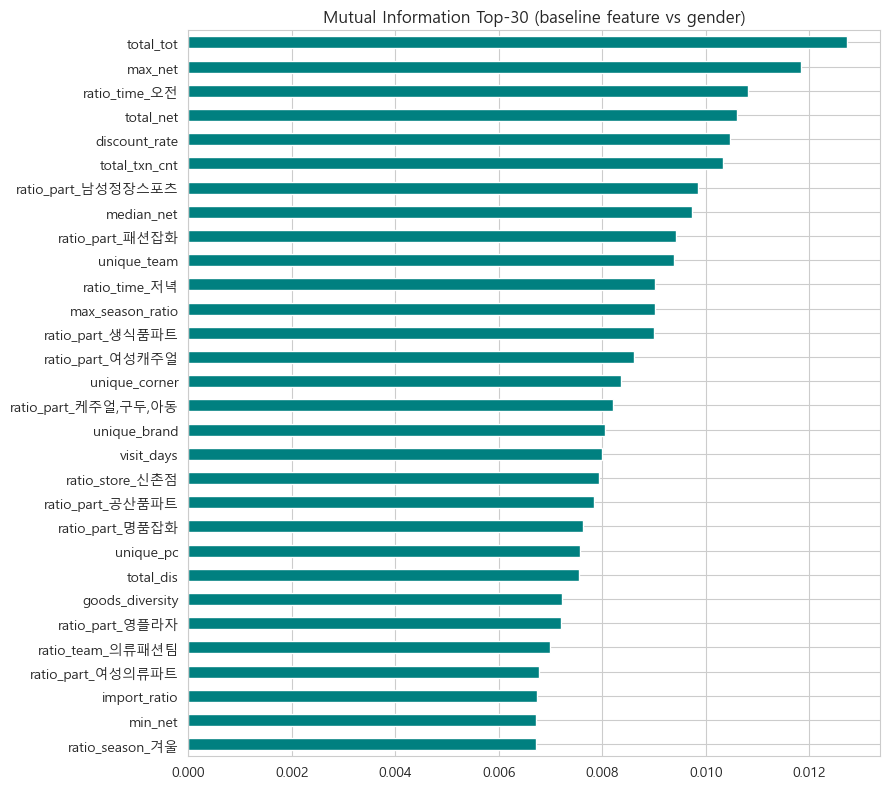

In [20]:
from sklearn.feature_selection import mutual_info_classif

X = cust[all_numeric].fillna(0).values
y = cust['gender'].values
mi = mutual_info_classif(X, y, random_state=42, n_jobs=-1)
mi_s = pd.Series(mi, index=all_numeric).sort_values(ascending=False)
display(mi_s.head(30).to_frame('MI'))

plt.figure(figsize=(9,8))
mi_s.head(30).iloc[::-1].plot(kind='barh', color='teal')
plt.title('Mutual Information Top-30 (baseline feature vs gender)')
plt.tight_layout(); plt.show()

### ***5. 시간 패턴 — 요일/시간/월 & baseline ratio_season_* / ratio_time_****

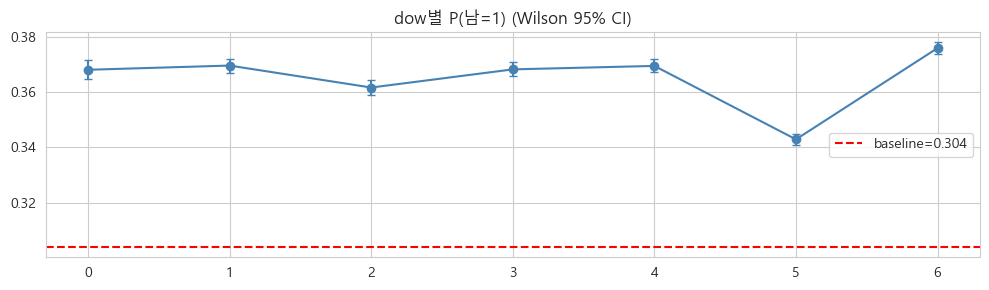

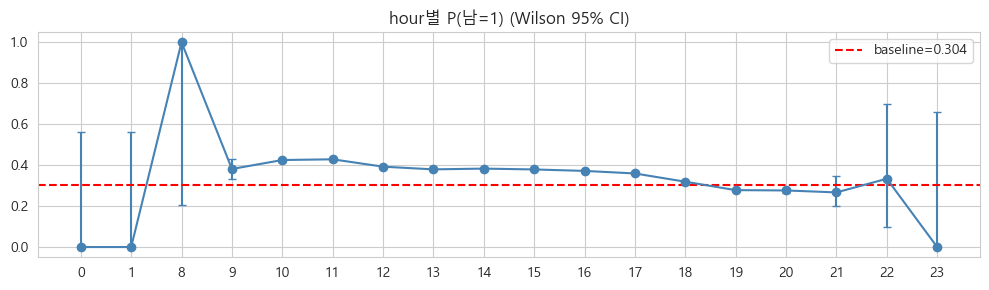

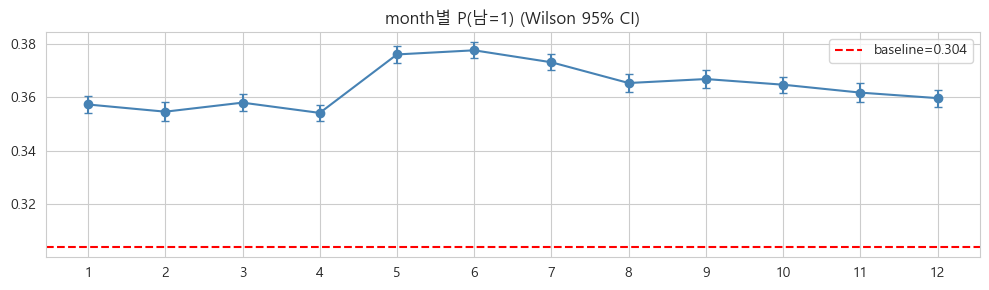

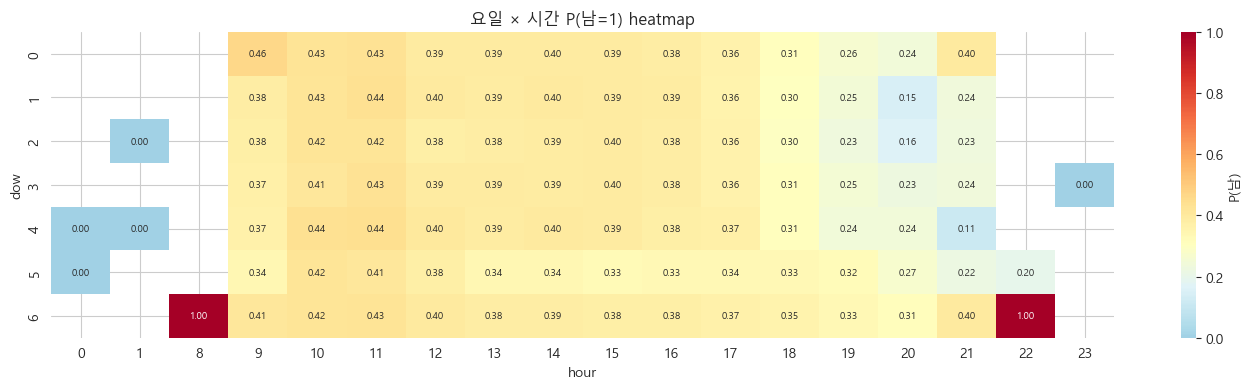

In [22]:
tx['dow']   = tx['sales_datetime'].dt.dayofweek
tx['hour']  = tx['sales_datetime'].dt.hour
tx['month'] = tx['sales_datetime'].dt.month

for col in ['dow','hour','month']:
    g = tx.groupby(col)['gender'].agg(['sum','count'])
    g['p'] = g['sum']/g['count']
    ci = g.apply(lambda r: wilson_ci(int(r['sum']), int(r['count'])), axis=1)
    g['lo']=[c[0] for c in ci]; g['hi']=[c[1] for c in ci]
    g = g.reset_index()
    plt.figure(figsize=(10,3))
    plt.errorbar(g[col].astype(str), g['p'],
                 yerr=[g['p']-g['lo'], g['hi']-g['p']],
                 fmt='o-', capsize=3, color='steelblue')
    plt.axhline(base_p_male, color='red', ls='--', label=f'baseline={base_p_male:.3f}')
    plt.title(f'{col}별 P(남=1) (Wilson 95% CI)')
    plt.legend(); plt.tight_layout(); plt.show()

pivot = tx.groupby(['dow','hour'])['gender'].mean().unstack().sort_index()
plt.figure(figsize=(14,4))
sns.heatmap(pivot, cmap='RdYlBu_r', center=base_p_male,
            annot=True, fmt='.2f', annot_kws={'size':7}, cbar_kws={'label':'P(남)'})
plt.title('요일 × 시간 P(남=1) heatmap'); plt.tight_layout(); plt.show()

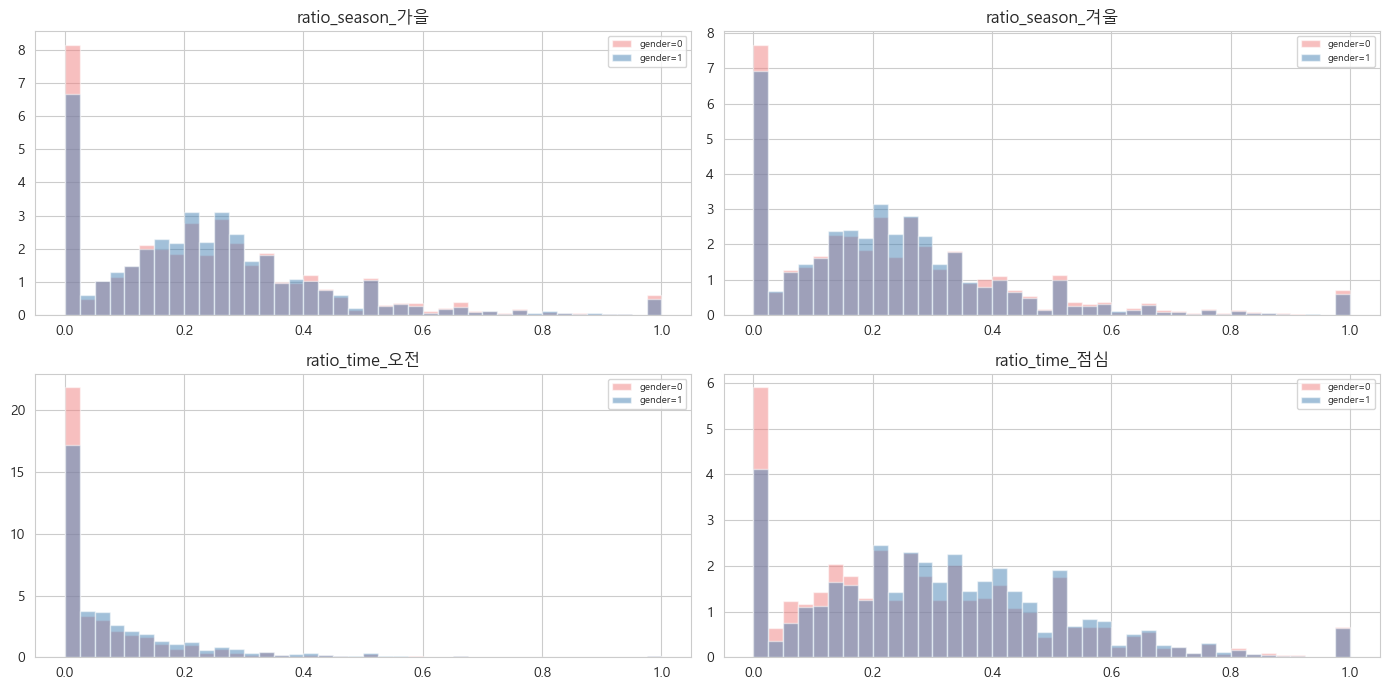

#### season/time 별 평균 비중 — 성별 비교

gender,0,1
ratio_season_가을,0.2348,0.2364
ratio_season_겨울,0.2351,0.2273
ratio_season_봄,0.2850,0.2749
ratio_season_여름,0.2452,0.2614
ratio_time_오전,0.0694,0.0936
ratio_time_점심,0.2837,0.3142
ratio_time_오후,0.3897,0.4004
ratio_time_저녁,0.2571,0.1917


In [23]:
# baseline의 ratio_season_* / ratio_time_* 가 성별과 어떻게 연관되는지
fig, axes = plt.subplots(2,2, figsize=(14,7))
for ax, c in zip(axes[0], season_cols[:2]):
    for gv,color in [(0,'lightcoral'),(1,'steelblue')]:
        ax.hist(cust.loc[cust['gender']==gv,c], bins=40, alpha=0.5,
                color=color, label=f'gender={gv}', density=True)
    ax.set_title(c); ax.legend(fontsize=7)
for ax, c in zip(axes[1], time_cols[:2]):
    for gv,color in [(0,'lightcoral'),(1,'steelblue')]:
        ax.hist(cust.loc[cust['gender']==gv,c], bins=40, alpha=0.5,
                color=color, label=f'gender={gv}', density=True)
    ax.set_title(c); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

# season/time 별 평균 비중 성별 비교
display(Markdown('#### season/time 별 평균 비중 — 성별 비교'))
display(cust.groupby('gender')[season_cols+time_cols].mean().T.round(4))

### ***6. 행동/집중도 feature 성별 분리도***

> baseline의 핵심 비율 feature(`refund_ratio`, `import_ratio`, `installment_ratio`, `weekend_ratio`,
> `max_team_ratio`, `max_part_ratio`, `max_season_ratio`)가 두 성별 그룹을 얼마나 분리하는지 본다.

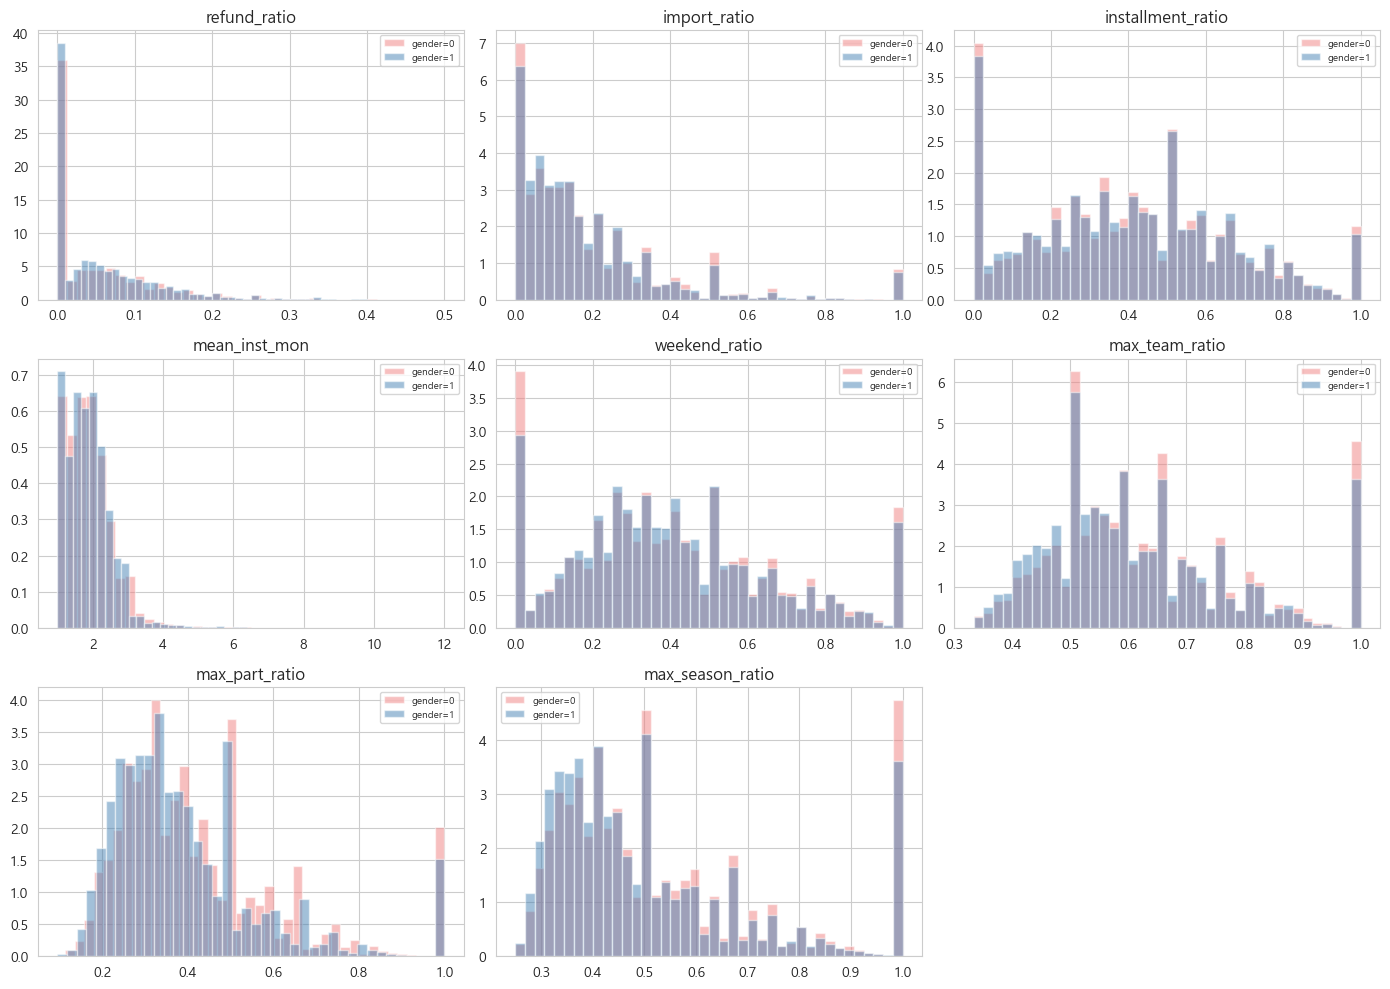

#### 성별 평균/중앙값 비교

refund_ratio         import_ratio        installment_ratio         \
               mean  median         mean median              mean median   
gender                                                                     
0            0.0524  0.0286       0.1810  0.125            0.4034    0.4   
1            0.0550  0.0370       0.1748  0.125            0.4016    0.4   

       mean_inst_mon         weekend_ratio         max_team_ratio          \
                mean  median          mean  median           mean  median   
gender                                                                      
0             1.9091  1.8333        0.3986  0.3673         0.6280  0.6000   
1             1.8853  1.8182        0.3971  0.3659         0.6102  0.5789   

       max_part_ratio         max_season_ratio          
                 mean  median             mean  median  
gender                                                  
0              0.4239  0.3778           0.5259  0.4688  
1              0.3921  0.3462           0.4990  0.4419

In [25]:
behavior_full = beh_cols + conc_cols
fig, axes = plt.subplots(3,3, figsize=(14,10))
for ax, c in zip(axes.flatten(), behavior_full):
    for gv,color in [(0,'lightcoral'),(1,'steelblue')]:
        s = cust.loc[cust['gender']==gv, c].dropna()
        ax.hist(s, bins=40, alpha=0.5, color=color, label=f'gender={gv}', density=True)
    ax.set_title(c); ax.legend(fontsize=7)
for ax in axes.flatten()[len(behavior_full):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

display(Markdown('#### 성별 평균/중앙값 비교'))
display(cust.groupby('gender')[behavior_full].agg(['mean','median']).round(4))

In [26]:
# team / part 비중의 성별 평균 차이 — 어떤 팀/파트가 성별 구분력이 큰가
team_diff = cust.groupby('gender')[team_cols].mean().T
team_diff['diff(남-여)'] = team_diff[1] - team_diff[0]
team_diff = team_diff.sort_values('diff(남-여)', ascending=False)
display(Markdown('#### ratio_team_* — 성별 평균 차이'))
display(team_diff)

part_diff = cust.groupby('gender')[part_cols].mean().T
part_diff['diff(남-여)'] = part_diff[1] - part_diff[0]
part_diff = part_diff.sort_values('diff(남-여)', ascending=False)
display(Markdown('#### ratio_part_* — 성별 평균 차이 (상/하위 10)'))
display(pd.concat([part_diff.head(10), part_diff.tail(10)]))

#### ratio_team_* — 성별 평균 차이

gender,0,1,diff(남-여)
ratio_team_식품팀,0.145454,0.172631,0.027177
ratio_team_상품개발영업2과,0.000000,0.000001,0.000001
ratio_team_인터넷백화점,0.000001,0.000000,-0.000001
ratio_team_의류패션팀,0.326816,0.321109,-0.005707
ratio_team_잡화가용팀,0.527729,0.506259,-0.021471


#### ratio_part_* — 성별 평균 차이 (상/하위 10)

gender,0,1,diff(남-여)
"ratio_part_케주얼,구두,아동",0.055135,0.075922,0.020787
ratio_part_남성정장스포츠,0.016999,0.033826,0.016827
ratio_part_남성의류,0.031481,0.045469,0.013988
ratio_part_생식품파트,0.013285,0.024840,0.011555
ratio_part_공산품파트,0.021649,0.032914,0.011264
"ratio_part_아동,스포츠",0.030650,0.040240,0.009590
ratio_part_골프/유니캐쥬얼,0.028644,0.037110,0.008465
ratio_part_가정용품파트,0.011460,0.017898,0.006438
ratio_part_생식품,0.040108,0.046462,0.006354
ratio_part_잡화파트,0.087880,0.093719,0.005839


### ***7. Feature Importance 사전 평가***

> baseline feature 전체를 가벼운 모델 두 종(Logistic + RF)에 넣어 어떤 feature가 즉시 신호를 가지는지 확인.
> 본격 AutoGluon 학습 전 sanity check 용도.

Logistic 3-fold AUC: 0.6830
RandomForest 3-fold AUC: 0.6737


,rf_importance
discount_rate,0.035395
ratio_time_저녁,0.026296
total_dis,0.025285
max_net,0.024102
min_net,0.023410
amt_per_visit,0.023181
median_net,0.023132
mean_net,0.022816
total_net,0.022330
std_net,0.022318


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

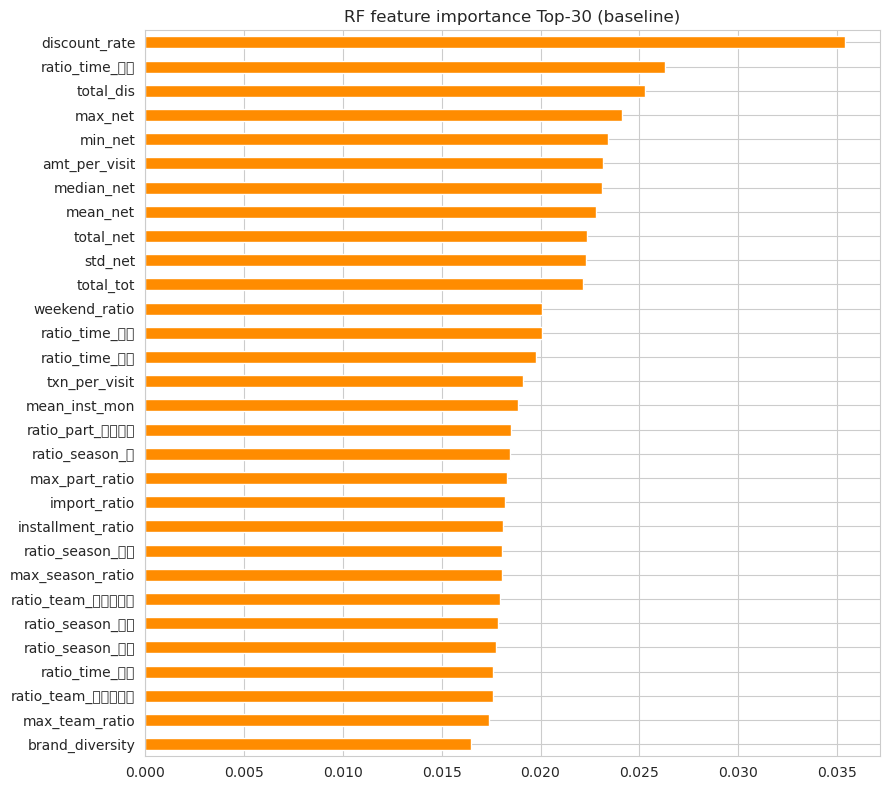

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# AUTO-INJECTED: Korean font setup for matplotlib
import os as _os
import matplotlib.font_manager as _fm
import matplotlib.pyplot as _plt
if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
    for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                  '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
        if _os.path.exists(_font):
            _fm.fontManager.addfont(_font)
_plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
del _os, _fm, _plt
# END AUTO-INJECTED Korean font setup


X = cust[all_numeric].fillna(0).values
y = cust['gender'].values

# (1) Logistic (표준화) — 선형 신호
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
lr = LogisticRegression(max_iter=2000, n_jobs=-1)
auc_lr = cross_val_score(lr, Xs, y, cv=3, scoring='roc_auc', n_jobs=-1).mean()
print(f'Logistic 3-fold AUC: {auc_lr:.4f}')

# (2) RandomForest — 비선형 + feature importance
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
auc_rf = cross_val_score(rf, X, y, cv=3, scoring='roc_auc', n_jobs=-1).mean()
print(f'RandomForest 3-fold AUC: {auc_rf:.4f}')

rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=all_numeric).sort_values(ascending=False)
display(imp.head(30).to_frame('rf_importance'))

plt.figure(figsize=(9,8))
imp.head(30).iloc[::-1].plot(kind='barh', color='darkorange')
plt.title('RF feature importance Top-30 (baseline)')
plt.tight_layout(); plt.show()

### ***8. Summary & Feature Engineering 체크리스트***

In [30]:
ideas = [
    "[Log 변환] total_net/total_tot/max_net/total_dis 등 high-skew는 log1p 추가 — 선형/거리 기반 모델 안정화",
    "[고객 단위 환불 강도] refund_count, refund_amt_sum, refund_amt_ratio — 현재 refund_ratio(횟수 비율)만 있음",
    "[최근성 Recency] 마지막 거래일~기간 종료일 일수, 최근 30/90일 거래 비율 — baseline엔 없음",
    "[방문 간격 패턴] 방문 간격 평균/표준편차, 최근 방문 가속도 — 충성도/이탈 시그널",
    "[Premium index] 명품 카테고리(team='잡화가용팀' 등 lift 큰 그룹) × import_flg 결합 비율",
    "[브랜드 lift encoding] brd_nm 단위 P(남) target encoding (OOF) — 현재 brand는 unique_brand 카운트만 사용",
    "[Top brand affinity] 고객별 상위 노출 브랜드 K개 one-hot/lift weighted — high-card 처리",
    "[Item embedding] starter의 Word2Vec(corner_nm)을 brd_nm/goodcd로 확장, 가중평균(거래액·최근성) 적용",
    "[Cross feature] str_nm × team_nm 비중, corner_nm × time_zone 비중 — baseline은 단일 축 비중만 존재",
    "[금액 분위수] tot_amt 95/99 percentile, 단일 고가 거래 빈도",
    "[다양성 비율] unique_part/unique_team, unique_corner/unique_pc 등 계층 다양성 ratio",
    "[ratio entropy] team/part/season/time 비중의 엔트로피 — '얼마나 분산되어 소비하는가' 단일 지표",
    "[시간대 변동성] 요일/시간별 거래액 변동계수(CV) — 규칙적 vs 불규칙 구매 패턴",
]
print('━'*72)
print('🎯 Baseline 위에 얹을 Feature Engineering 체크리스트')
print('━'*72)
for i,t in enumerate(ideas,1):
    print(f'{i:2d}. {t}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 Baseline 위에 얹을 Feature Engineering 체크리스트
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. [Log 변환] total_net/total_tot/max_net/total_dis 등 high-skew는 log1p 추가 — 선형/거리 기반 모델 안정화
 2. [고객 단위 환불 강도] refund_count, refund_amt_sum, refund_amt_ratio — 현재 refund_ratio(횟수 비율)만 있음
 3. [최근성 Recency] 마지막 거래일~기간 종료일 일수, 최근 30/90일 거래 비율 — baseline엔 없음
 4. [방문 간격 패턴] 방문 간격 평균/표준편차, 최근 방문 가속도 — 충성도/이탈 시그널
 5. [Premium index] 명품 카테고리(team='잡화가용팀' 등 lift 큰 그룹) × import_flg 결합 비율
 6. [브랜드 lift encoding] brd_nm 단위 P(남) target encoding (OOF) — 현재 brand는 unique_brand 카운트만 사용
 7. [Top brand affinity] 고객별 상위 노출 브랜드 K개 one-hot/lift weighted — high-card 처리
 8. [Item embedding] starter의 Word2Vec(corner_nm)을 brd_nm/goodcd로 확장, 가중평균(거래액·최근성) 적용
 9. [Cross feature] str_nm × team_nm 비중, corner_nm × time_zone 비중 — baseline은 단일 축 비중만 존재
10. [금액 분위수] tot_amt 95/99 percentile, 단일 고가 거래 빈도
11. [다양성 비율] unique_part/unique